# Data Preparation
### Fetch Historical Data from yfinance

In [2]:
import yfinance as yf
import pandas as pd

def load_historical_btc():
    # df = yf.download('BTC-USD', start='2013-01-01', interval='1d')
    df = yf.download("BTC-USD", start="2013-04-28", interval='1d')  # First BTC Yahoo date
    df = df[['Close']].rename(columns={'Close': 'price'})
    df.reset_index(inplace=True)
    df['timestamp'] = pd.to_datetime(df['Date'])
    df = df[['timestamp', 'price']].dropna()
    return df

btc_hist = load_historical_btc()
btc_hist.columns = ['timestamp', 'price']
print(btc_hist.tail())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

      timestamp         price
3875 2025-04-27  93754.843750
3876 2025-04-28  94978.750000
3877 2025-04-29  94284.789062
3878 2025-04-30  94207.312500
3879 2025-05-01  96742.093750


In [3]:
btc_hist.tail()

,timestamp,price
3875,2025-04-27,93754.843750
3876,2025-04-28,94978.750000
3877,2025-04-29,94284.789062
3878,2025-04-30,94207.312500
3879,2025-05-01,96742.093750


### Normalize and Sequence the Data

In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Normalize the price
scaler = MinMaxScaler()
btc_hist['scaled_price'] = scaler.fit_transform(btc_hist[['price']])

# Step 2: Create sequences
def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])     # Sequence of 30
        y.append(data[i+seq_len])       # Target is next day's price
    return np.array(X), np.array(y)

# Parameters
sequence_length = 30

# Step 3: Apply to scaled data
X, y = create_sequences(btc_hist['scaled_price'].values, sequence_length)

# Reshape for transformer: [batch, seq_len, features]
X = X.reshape(X.shape[0], sequence_length, 1)

# Confirm shape
print("X shape:", X.shape)  # (samples, 30, 1)
print("y shape:", y.shape)  # (samples,)

X shape: (3850, 30, 1)
y shape: (3850,)


# Transformer Model in PyTorch
###  Define the Model

In [5]:
import torch
import torch.nn as nn

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()
        
        self.model_type = 'Transformer'
        self.input_dim = input_dim
        self.d_model = d_model

        # Project input to d_model dimensions
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.randn(5000, d_model))

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output regression head
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, src):
        """
        src shape: [batch_size, seq_len, input_dim]
        """
        batch_size, seq_len, _ = src.shape

        # Project input
        src = self.input_projection(src)

        # Add positional encoding
        pe = self.positional_encoding[:seq_len, :].unsqueeze(0).repeat(batch_size, 1, 1)
        src = src + pe

        # Transpose for transformer: [seq_len, batch_size, d_model]
        src = src.permute(1, 0, 2)

        # Pass through transformer encoder
        transformer_output = self.transformer_encoder(src)

        # Take the last time step's output
        out = transformer_output[-1, :, :]  # shape: [batch_size, d_model]

        # Predict next price
        return self.output_layer(out)

### Setup Training Framework

In [6]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Prepare dataset
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

### Training Loop

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimeSeriesTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_output = model(X_val_batch)
            val_loss += criterion(val_output, y_val_batch).item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

/opt/anaconda3/envs/data605_env/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1, Train Loss: 2.2599, Val Loss: 0.0252
Epoch 2, Train Loss: 0.3785, Val Loss: 0.0047
Epoch 3, Train Loss: 0.2658, Val Loss: 0.0068
Epoch 4, Train Loss: 0.2074, Val Loss: 0.0045
Epoch 5, Train Loss: 0.1777, Val Loss: 0.0072
Epoch 6, Train Loss: 0.1684, Val Loss: 0.0104
Epoch 7, Train Loss: 0.1596, Val Loss: 0.0036
Epoch 8, Train Loss: 0.1310, Val Loss: 0.0107
Epoch 9, Train Loss: 0.1273, Val Loss: 0.0061
Epoch 10, Train Loss: 0.1149, Val Loss: 0.0063
Epoch 11, Train Loss: 0.1088, Val Loss: 0.0029
Epoch 12, Train Loss: 0.1047, Val Loss: 0.0028
Epoch 13, Train Loss: 0.1009, Val Loss: 0.0048
Epoch 14, Train Loss: 0.0993, Val Loss: 0.0063
Epoch 15, Train Loss: 0.0977, Val Loss: 0.0034
Epoch 16, Train Loss: 0.0887, Val Loss: 0.0033
Epoch 17, Train Loss: 0.0947, Val Loss: 0.0056
Epoch 18, Train Loss: 0.0848, Val Loss: 0.0028
Epoch 19, Train Loss: 0.0843, Val Loss: 0.0041
Epoch 20, Train Loss: 0.0808, Val Loss: 0.0113


# Evaluation & Prediction Visualization
### Predict on Validation Set

In [8]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch).cpu().numpy()
        predictions.extend(output)
        actuals.extend(y_batch.numpy())

### Inverse Transform to Real Prices

In [9]:
# Reshape and inverse scale
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))

### Visualize Predictions vs Actual

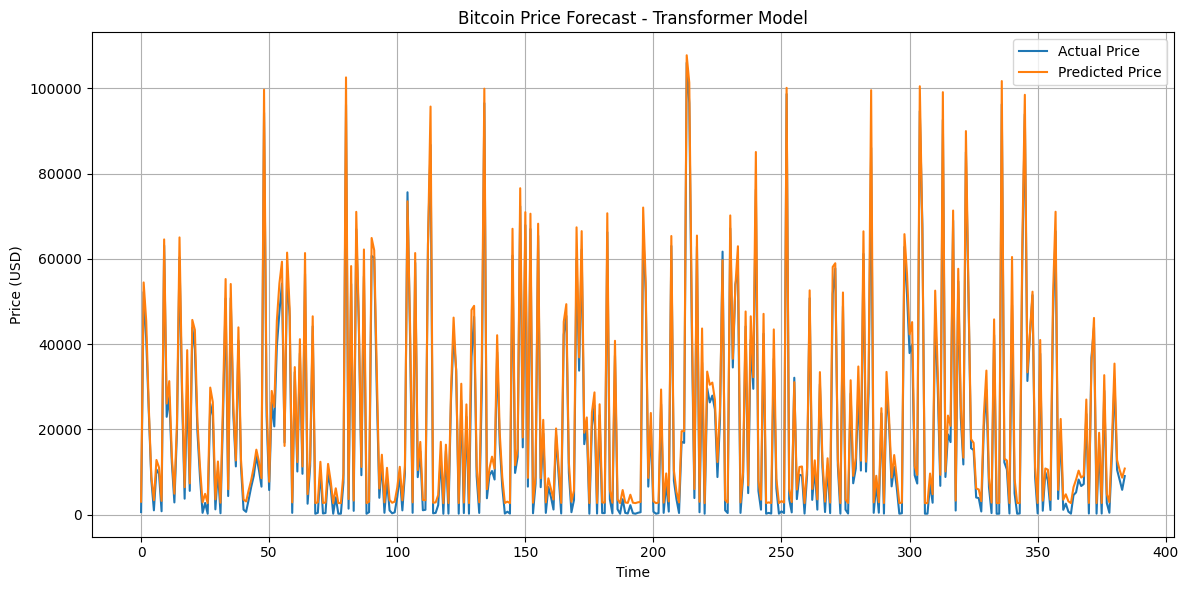

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title("Bitcoin Price Forecast - Transformer Model")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Performance Metrics

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 2828.27, RMSE: 3208.69


### Next Day BTC price

In [14]:
def predict_future_prices(model, last_sequence, n_days=7, scaler=None, device='cpu'):
    """
    Predicts the next `n_days` of Bitcoin prices based on the last `sequence_length` days.
    Assumes `last_sequence` is already scaled.
    """
    model.eval()
    predictions = []
    current_seq = last_sequence.copy()

    for _ in range(n_days):
        input_seq = torch.tensor(current_seq.reshape(1, -1, 1), dtype=torch.float32).to(device)
        with torch.no_grad():
            pred = model(input_seq).cpu().numpy()[0][0]
        predictions.append(pred)
        current_seq = np.append(current_seq[1:], pred)  # Shift window

    # Inverse transform to original scale
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

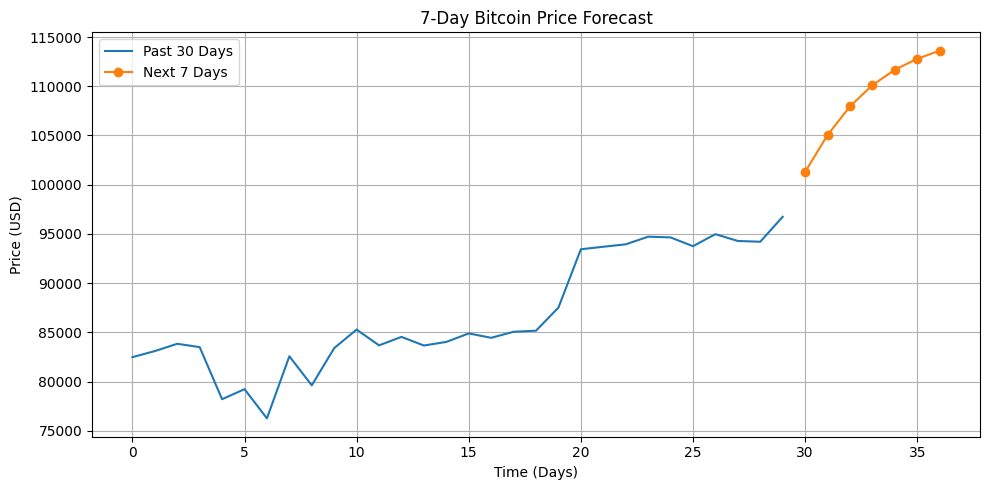

In [15]:
# Get the last scaled sequence (most recent 30 days)
last_scaled_seq = btc_hist['scaled_price'].values[-sequence_length:]

# Forecast next 7 days
future_scaled_preds = predict_future_prices(model, last_scaled_seq, n_days=7, scaler=scaler, device=device)

# Plot the forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(30), scaler.inverse_transform(last_scaled_seq.reshape(-1, 1)), label="Past 30 Days")
plt.plot(range(30, 37), future_scaled_preds, label="Next 7 Days", marker='o')
plt.title("7-Day Bitcoin Price Forecast")
plt.xlabel("Time (Days)")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Save the model for reuse

In [21]:
torch.save(model.state_dict(), "transformer_btc_model.pth")

# Save the scaler for future use
import joblib
joblib.dump(scaler, "btc_scaler.save")

['btc_scaler.save']

# Load Model for Later Use

In [23]:
# Recreate the model architecture
model_loaded = TimeSeriesTransformer().to(device)

# Load the scaler
scaler = joblib.load("btc_scaler.save")

# Load saved weights
model_loaded.load_state_dict(torch.load("transformer_btc_model.pth", map_location=device))
model_loaded.eval()


/var/folders/ns/mp2t798n28l81cvv4hpmdpyr0000gn/T/ipykernel_65116/1975246220.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loaded.load_state_dict(torch.load("tran

TimeSeriesTransformer(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)